# Most Waffle Houses are in just five states

**Finding:** Of the **2,006** Waffle House locations in this dataset,
**57.2% (1,147)** are in only **five states** — Georgia, Florida, North
Carolina, South Carolina, and Alabama. More than half the chain sits in five of
the fifty states.

This notebook is the *editor test*: it documents the source, runs data-quality
checks, then reproduces the number step-by-step from the raw file with a chart,
and ends with limitations. Run it top to bottom (`Kernel → Restart & Run All`)
to verify the claim from scratch.


## Data source

- **File:** `waffle_houses.csv` — a point-in-time export of Waffle House store
  locations (one row per location).
- **Records:** 2,006 rows, 14 columns (Store Code, Business Name, Address, City,
  State, Postal Code, Country, Latitude, Longitude, Phone, Website, Operated By,
  Online Order Link, Business Hours).
- **Full column documentation and the original QA write-up:** see
  [`DATA_DICTIONARY.md`](DATA_DICTIONARY.md) in this repository.
- **Nature:** a snapshot. Counts reflect locations present in this export, not a
  live or historical census.


In [1]:
import pandas as pd

# Read everything as strings first (per the data dictionary: keep Store Code and
# Postal Code as text so the 'WH_Museum' id and any leading zeros survive),
# then convert only the coordinate columns to float.
df = pd.read_csv("waffle_houses.csv", dtype=str)
df["Latitude"] = df["Latitude"].astype(float)
df["Longitude"] = df["Longitude"].astype(float)

print("shape:", df.shape)
df.head()

shape: (2006, 14)


,Store Code,Business Name,Address,City,State,Postal Code,Country,Latitude,Longitude,Phone Number,Website URL,Operated By,Online Order Link,Formatted Business Hours
0,100,Waffle House #100,2842 PANOLA RD,LITHONIA,GA,30058,US,33.704706,-84.169849,(770) 981-1914,https://locations.wafflehouse.com///lithonia-g...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
1,1000,Waffle House #1000,2850 E COLLEGE AVE,DECATUR,GA,30030,US,33.775215,-84.273744,(404) 294-8758,https://locations.wafflehouse.com///decatur-ga...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
2,1001,Waffle House #1001,12923 SHELBYVILLE RD,LOUISVILLE,KY,40243,US,38.243594,-85.513206,(502) 244-1005,https://locations.wafflehouse.com///louisville...,"FULLY OWNED SUBSIDIARY: MIDWEST WAFFLES, INC.",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
3,1002,Waffle House #1002,1161 RAMBLING OAKS DR,NORMAN,OK,73072,US,35.232444,-97.489044,(405) 364-4901,https://locations.wafflehouse.com///norman-ok-...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
4,1003,Waffle House #1003,1002 HWY 90,BAY SAINT LOUIS,MS,39520,US,30.313246,-89.356576,(228) 466-6688,https://locations.wafflehouse.com///baysaintlo...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours


## Quality checks (before trusting any number)

These reproduce the key checks from `DATA_DICTIONARY.md`: total rows, missing
values, duplicate IDs, the known non-restaurant outlier (the Waffle House
Museum), and the number of distinct states.


In [2]:
n = len(df)
print(f"Row count: {n}")

# Missing values per column (only show columns that have any)
missing = df.isna().sum()
print("\nMissing values:")
print(missing[missing > 0].to_string() or "  (none)")

# Duplicate Store Codes -> expect 0
dups = df["Store Code"].duplicated().sum()
print(f"\nDuplicate Store Codes: {dups}")

# The museum row: a non-restaurant outlier (non-numeric id, blank fields)
museum = df[df["Store Code"] == "WH_Museum"]
print(f"\nMuseum rows (non-restaurant): {len(museum)}")
print(museum[["Store Code", "Business Name", "City", "State"]].to_string(index=False))

# Distinct states
print(f"\nDistinct states present: {df['State'].nunique()}")

assert n == 2006, "expected 2,006 rows"
assert dups == 0, "Store Code should be unique"
print("\nQA summary: PASS — 2,006 unique-id rows, 25 states, 1 flagged museum outlier.")

Row count: 2006

Missing values:
Operated By                 1
Online Order Link           3
Formatted Business Hours    2

Duplicate Store Codes: 0

Museum rows (non-restaurant): 1
Store Code                  Business Name    City State
 WH_Museum Waffle House Museum #WH_Museum Decatur    GA

Distinct states present: 25

QA summary: PASS — 2,006 unique-id rows, 25 states, 1 flagged museum outlier.


## Reproduce the finding, step by step

Count locations per state, take the top five, and compute their combined share
of all locations — showing the arithmetic explicitly.


In [3]:
counts = df["State"].value_counts()          # locations per state, descending
top5 = counts.head(5)
top5_sum = int(top5.sum())
total = len(df)
share = 100 * top5_sum / total

print("Top 5 states:")
for state, c in top5.items():
    print(f"  {state}: {c}")
print(f"\nSum of top 5 : {top5_sum}")
print(f"Total records: {total}")
print(f"Share        : {top5_sum} / {total} = {share:.1f}%")

Top 5 states:
  GA: 442
  FL: 188
  NC: 186
  SC: 175
  AL: 156

Sum of top 5 : 1147
Total records: 2006
Share        : 1147 / 2006 = 57.2%


**Robustness check** — does the one non-restaurant museum row change the answer?
Recompute excluding it.


In [4]:
rest = df[df["Store Code"] != "WH_Museum"]          # 2,005 operating restaurants
r_counts = rest["State"].value_counts()
r_top5 = int(r_counts.head(5).sum())
print(f"Excluding the museum: {r_top5} / {len(rest)} = {100*r_top5/len(rest):.1f}%")
print("=> The museum row does not move the finding.")

Excluding the museum: 1146 / 2005 = 57.2%
=> The museum row does not move the finding.


## Chart: locations by state, top five highlighted


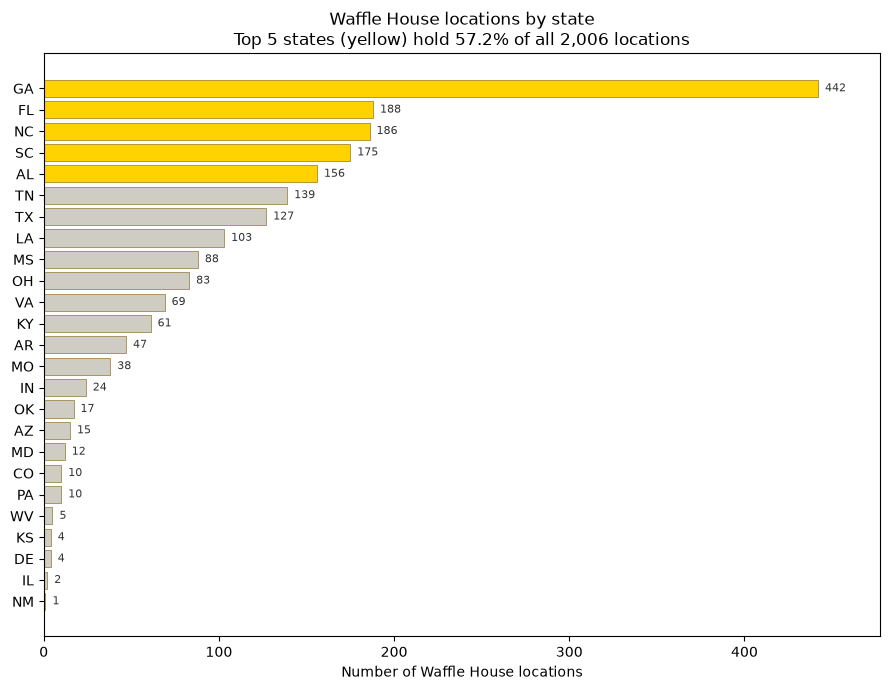

In [5]:
import matplotlib.pyplot as plt

WH_YELLOW, GRAY = "#FFD200", "#cfccc4"
top5_states = list(top5.index)
colors = [WH_YELLOW if s in top5_states else GRAY for s in counts.index]

fig, ax = plt.subplots(figsize=(9, 7))
y = range(len(counts))
ax.barh(y, counts.values, color=colors, edgecolor="#7a5b00", linewidth=0.4)
ax.set_yticks(list(y))
ax.set_yticklabels(counts.index)
ax.invert_yaxis()                                   # highest at top
ax.set_xlabel("Number of Waffle House locations")
ax.set_title("Waffle House locations by state\nTop 5 states (yellow) hold "
             f"{share:.1f}% of all {total:,} locations")
for i, v in enumerate(counts.values):
    ax.text(v + 4, i, str(v), va="center", fontsize=8, color="#333")
ax.margins(x=0.08)
plt.tight_layout()
plt.show()

## Limitations

- **Snapshot, not a census.** The file is a point-in-time export; counts reflect
  locations present in *this* data, not openings/closings over time.
- **"Five of fifty" framing.** The chain operates in 25 states; the other 25 have
  zero locations. The "fifty states" comparison excludes DC and territories.
- **The museum is included in the 2,006 total.** It is a non-restaurant outlier;
  as shown above, excluding it leaves the finding unchanged (57.2%).
- **Share of *locations*, not people or land.** This measures where stores are,
  not per-capita density or market penetration.
- **Known data caveats don't affect this count.** The website-URL `///` artifact
  and the 229 rows holding two phone numbers (see `DATA_DICTIONARY.md`) touch
  other columns, not `State`, so they don't change these figures.
